In [1]:
import sys
sys.path.append("D:/metal-flow/src/metal_flow")

Generating Launchpads...
Generating CoupledLineTee
Connecting...
Generating Qubits...
Generating Readout Resonators...
Generating Couplers...


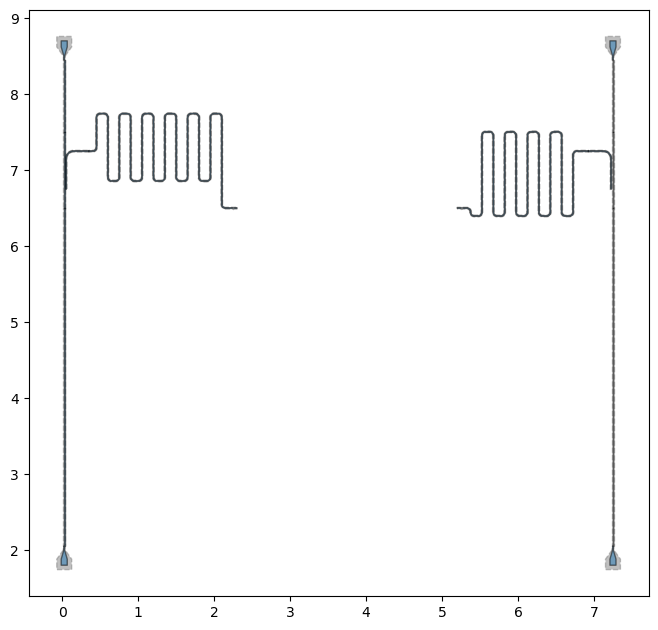

In [2]:
from qiskit_metal import Dict, view

# Import create_design and the wavelength calculator from your functions file
from functions import create_design, cal_cpw_wavelength_dict

from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander

FOUR_QUBIT_DESIGN_DICT = Dict(
    chip_size = Dict(
        size_x = '10mm',
        size_y = '10mm',
        size_z = '-280um',
        centre_x = '4mm',
        centre_y = '5mm'
    ),

    cpw_dims = Dict(
        width = '10 um',
        gap = '6 um'
    ),

    physical_params = Dict(
        substrate_thickness = 280e-6,
        film_thickness = 200e-9
    ),

    launchpad_options = Dict(
        p0 = Dict(pos_x='25um'  , pos_y='8500um', orientation='-90', lead_length='50 um', pad_width='80 um', pad_height='80 um'),
        p1 = Dict(pos_x='7250um', pos_y='8500um', orientation='-90', lead_length='50 um', pad_width='80 um', pad_height='80 um'),
        p2 = Dict(pos_x='25um'  , pos_y='2000um', orientation='90' , lead_length='50 um', pad_width='80 um', pad_height='80 um'),
        p3 = Dict(pos_x='7250um', pos_y='2000um', orientation='90' , lead_length='50 um', pad_width='80 um', pad_height='80 um')
    ),

    cpw_default_options = Dict(chip='main', hfss_wire_bonds=True),

    feedline_connections = [
        # Left Feedline
        Dict(start_pin=Dict(component='p0', pin='tie'), end_pin=Dict(component='ctl0', pin='prime_end')), 
        Dict(start_pin=Dict(component='ctl0', pin='prime_start'), end_pin=Dict(component='p2', pin='tie')),
        #Dict(start_pin=Dict(component='ctl2', pin='prime_start'), end_pin=Dict(component='p2', pin='tie')),
        
        # Right Feedline
        Dict(start_pin=Dict(component='p1', pin='tie'), end_pin=Dict(component='ctl1', pin='prime_start')), 
        Dict(start_pin=Dict(component='ctl1', pin='prime_end'), end_pin=Dict(component='p3', pin='tie')),
        #Dict(start_pin=Dict(component='ctl3', pin='prime_end'), end_pin=Dict(component='p3', pin='tie'))
    ],

    coupled_tline_params = Dict(
        ctl0= Dict(pos_x='25um'  , pos_y='7000um', open_termination=True, orientation=90 , down_length='300um', coupling_length='500um', fillet='100um', mirror=False),
        ctl1= Dict(pos_x='7250um', pos_y='7000um', open_termination=True, orientation=-90, down_length='300um', coupling_length='500um', fillet='100um', mirror=True),
        # ctl2= Dict(pos_x='25um'  , pos_y='3000um', open_termination=True, orientation=90 , down_length='300um', coupling_length='500um', fillet='100um', mirror=False),
        # ctl3= Dict(pos_x='7250um', pos_y='3200um', open_termination=True, orientation=-90, down_length='300um', coupling_length='500um', fillet='100um', mirror=True)
    ),

    # Target bare frequencies for the readout resonators
    resonator_frequencies_ghz = Dict(
        res_0 = 6.2,
        res_1 = 6.7,
        # res_2 = 7.1,
        # res_3 = 7.3
    ),

    # EMPTY DICTIONARIES: 
    # These prevent the loops inside functions.py from crashing since we removed the qubits
    qubit_options = Dict(),
    readout_map = []
)


if __name__ == '__main__':
    # 1. Initialize design (this will create feedlines, launchpads, and tees from functions.py)
    design = create_design(FOUR_QUBIT_DESIGN_DICT)

    # 2. Define the 4 OpenToGround terminations
    open_0 = OpenToGround(design, 'open_0', options=dict(pos_x='2250um', pos_y='6500um', orientation='180', width='10um', gap='6um'))
    open_1 = OpenToGround(design, 'open_1', options=dict(pos_x='5250um', pos_y='6500um', orientation='0',   width='10um', gap='6um'))
    # open_2 = OpenToGround(design, 'open_2', options=dict(pos_x='2250um', pos_y='3500um', orientation='180', width='10um', gap='6um'))
    # open_3 = OpenToGround(design, 'open_3', options=dict(pos_x='5250um', pos_y='3500um', orientation='0',   width='10um', gap='6um'))

    # 3. Create a dummy pad dictionary matching standard CPW sizes 
    # cal_cpw_wavelength_dict requires this to parse widths for EM calculations
    dummy_pad = Dict(pad_width='10 um', pad_gap='6 um')

    # 4. Define the routing geometries manually 
    routing_configurations = [
        {'name': 'res_0', 'start_comp': 'ctl0', 'end_comp': 'open_0', 'freq': FOUR_QUBIT_DESIGN_DICT.resonator_frequencies_ghz.res_0, 'spacing': '150um', 'asym': '50um',   'lead': '100um'},
        {'name': 'res_1', 'start_comp': 'ctl1', 'end_comp': 'open_1', 'freq': FOUR_QUBIT_DESIGN_DICT.resonator_frequencies_ghz.res_1, 'spacing': '150um', 'asym': '300um',  'lead': '200um'},
        # {'name': 'res_2', 'start_comp': 'ctl2', 'end_comp': 'open_2', 'freq': FOUR_QUBIT_DESIGN_DICT.resonator_frequencies_ghz.res_2, 'spacing': '150um', 'asym': '300um',  'lead': '100um'},
        # {'name': 'res_3', 'start_comp': 'ctl3', 'end_comp': 'open_3', 'freq': FOUR_QUBIT_DESIGN_DICT.resonator_frequencies_ghz.res_3, 'spacing': '150um', 'asym': '-400um', 'lead': '200um'}
    ]

    # 5. Calculate lengths dynamically and instantiate resonators
    for config in routing_configurations:
        # Calculate dynamic lambda/4 length based on the frequency
        wavelength_data = cal_cpw_wavelength_dict(
            config['freq'], 
            dummy_pad, 
            **FOUR_QUBIT_DESIGN_DICT.physical_params
        )
        calculated_length = wavelength_data['lambda4_str']
        
        # Route the meander with the calculated length
        RouteMeander(design, config['name'], options=dict(
            pin_inputs=dict(
                start_pin=dict(component=config['start_comp'], pin='second_end'), 
                end_pin=dict(component=config['end_comp'], pin='open')
            ),
            # FIX 1: Give the router a 50um runway at the end instead of 0um
            lead=dict(start_straight=config['lead'], end_straight='70um'),
            meander=dict(spacing=config['spacing'], asymmetry=config['asym']),
            # FIX 2: Reduce fillet to 49um to avoid corner overlapping on short jog segments
            fillet='49um', 
            total_length=calculated_length, 
            hfss_wire_bonds=True
        ))

    # 6. Rebuild and view
    design.rebuild()
    view(design).savefig("design.png")